In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyfaidx
import ast

In [2]:
from dna_utils import reverse_complement_dna, process_gtf, process_a_chrom

In [3]:
data = pd.read_csv('/data/validation/ddd_asd_zhouetal/asd_discov.csv')
data1 = pd.read_csv('/data/validation/ddd_asd_zhouetal/asd_rep.csv')
data = pd.concat([data, data1])
print(data['Pheno'].value_counts())
data = data.loc[(data['Ref'].str.len() == 1) & (data['Alt'].str.len() == 1)].copy()
data = data.sort_values(by=['Chrom','Position']).reset_index(drop=True).copy()
print(data['Pheno'].value_counts())

Pheno
Affected      23950
Unaffected     7603
Uncertain        96
Name: count, dtype: int64
Pheno
Affected      21971
Unaffected     7123
Uncertain        93
Name: count, dtype: int64


/tmp/ipykernel_3092778/554434807.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/data/validation/ddd_asd_zhouetal/asd_discov.csv')


In [4]:
len(set(data1['VarID'])), len(data1)

(639, 645)

In [5]:
asd_variants = data[data['Pheno'] == 'Affected']
ct_variants = data[data['Pheno'] == 'Unaffected']
asd_variants.shape, ct_variants.shape

((21971, 43), (7123, 43))

In [6]:
ddd_variants = pd.read_csv('/data/validation/ddd_asd_zhouetal/ddd_other.csv')
ddd_variants['Pheno'].value_counts()

Pheno
Affected    45903
Name: count, dtype: int64

In [8]:
variants = []
for classification, dset in zip(['asd', 'control', 'ddd'], [asd_variants, ct_variants, ddd_variants]):
    temp = dset[['VarID', 'Chrom', 'Position', 'Ref', 'Alt', 'Pheno']].copy()
    temp['classification'] = classification
    variants.append(temp)
variants = pd.concat(variants)
variants = variants.loc[(variants['Ref'].str.len() == 1) & (variants['Alt'].str.len() == 1)]
# result.to_csv('ddd_asd_variants.csv', index=False)
variants = variants.rename(columns={'VarID': 'variant_id', 'Chrom': 'chrom', 'Position': 'pos', 'Ref': 'ref', 'Alt': 'alt'})
variants['chrom'] = 'chr' + variants['chrom'].astype(str)
variants = variants.sort_values(by=['chrom', 'pos']).reset_index(drop=True).copy()




In [11]:
variants

,variant_id,chrom,pos,ref,alt,Pheno,classification
0,1:871216:G:A,chr1,871216,G,A,Affected,ddd
1,1:874817:C:T,chr1,874817,C,T,Affected,asd
2,1:877862:T:C,chr1,877862,T,C,Affected,ddd
3,1:878022:G:A,chr1,878022,G,A,Affected,ddd
4,1:878673:A:T,chr1,878673,A,T,Affected,asd
...,...,...,...,...,...,...,...
70705,X:154227779:G:A,chrX,154227779,G,A,Unaffected,control
70706,X:154294217:G:C,chrX,154294217,G,C,Affected,asd
70707,X:154344464:G:A,chrX,154344464,G,A,Affected,ddd
70708,X:154490399:C:T,chrX,154490399,C,T,Affected,asd


In [17]:
all_results = []
gtf_s, fasta = process_gtf('/data/reference/gencode.v47lift37.basic.annotation.processed.tsv', 
                           '/data/reference/hg19/hg19.fa') 
assembly = 'hg19'
chroms = variants['chrom'].unique()
for chrom in chroms:
    curr_variants = variants[variants['chrom']==chrom][['variant_id', 'chrom','pos','ref','alt']].drop_duplicates().copy()
    chrom_gtf = gtf_s[gtf_s['chrom']==chrom]
    chrom_results = process_a_chrom(curr_variants, chrom_gtf, return_alt_cds=True)
    all_results.append(chrom_results)
all_results = pd.concat(all_results).reset_index(drop=True)
all_results['variant_id'] = all_results['variant_id'] + '_' + assembly


all_results = all_results.merge(variants.drop('variant_id', axis=1), left_on=['chrom','pos','ref','alt'], 
                                right_on=['chrom','pos','ref','alt'])

In [18]:
for i in range(variants.shape[0]):
    t = variants.iloc[i]
    variant_id = t['variant_id']
    chrom = t['chrom']
    pos = t['pos']
    ref = t['ref']
    alt = t['alt']
    hg19_ref = fasta[chrom][pos-1]
    if hg19_ref != ref:
        print(f"Mismatch at {chrom}:{pos}, {ref} != {hg19_ref}, {variant_id}")
 
    

In [19]:
all_results['variant_type'] = 'synonymous'
all_results.loc[(all_results['ref_aa'] != all_results['alt_aa']) & (all_results['alt_aa'] != '*'), 'variant_type'] = 'missense'
all_results.loc[(all_results['ref_aa'] != all_results['alt_aa']) & (all_results['alt_aa'] == '*'), 'variant_type'] = 'ptv'
all_results.loc[ (all_results['ref_aa'] == '*'), 'variant_type'] = 'in_stop'

In [15]:
all_results[['variant_type', 'classification']].value_counts()

variant_type  classification
missense      ddd               107919
              asd                47149
synonymous    ddd                29090
              asd                16889
missense      control            15050
ptv           ddd                14134
synonymous    control             5477
ptv           asd                 4560
              control              758
in_stop       ddd                  109
              asd                   66
              control               28
Name: count, dtype: int64

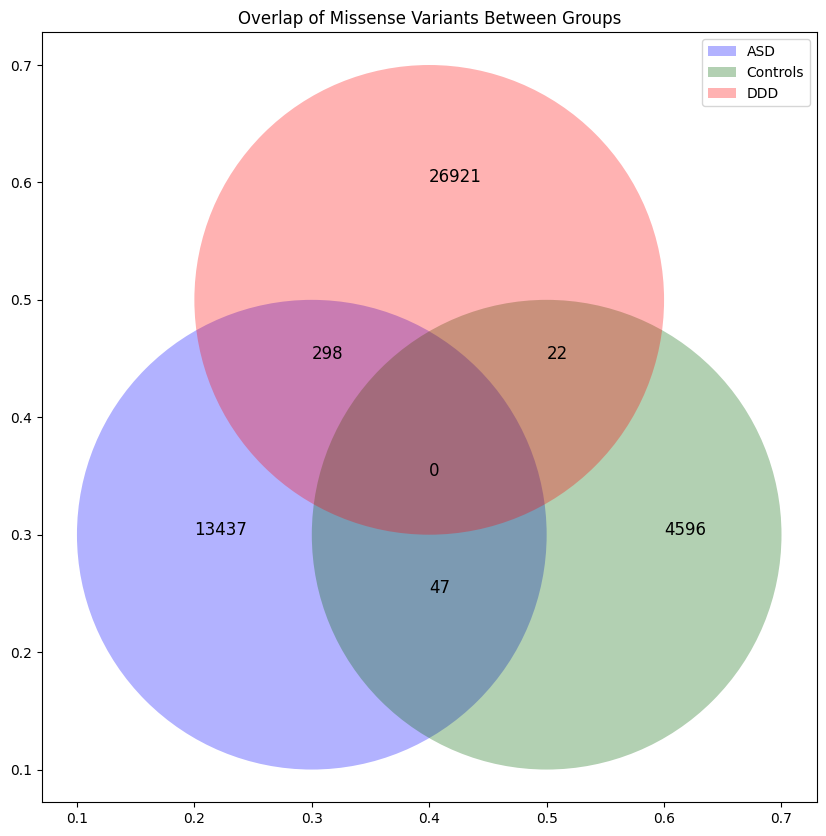


Total unique variants in each group:
ASD: 13782
Controls: 4665
DDD: 27241


In [20]:
# Get sets of variant IDs for each group
asd_varids = set( all_results[(all_results['classification'] == 'asd') & (all_results['variant_type'] == 'missense')]['variant_id'].unique())
ct_varids = set(all_results[(all_results['classification'] == 'control') & (all_results['variant_type'] == 'missense')]['variant_id'].unique())
ddd_varids = set(all_results[(all_results['classification'] == 'ddd') & (all_results['variant_type'] == 'missense')]['variant_id'].unique())

# Create Venn diagram using matplotlib circles
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

plt.figure(figsize=(10,10))

# Create three circles
circle1 = plt.Circle((0.3, 0.3), 0.2, alpha=0.3, fc='blue', label='ASD')
circle2 = plt.Circle((0.5, 0.3), 0.2, alpha=0.3, fc='darkgreen', label='Controls')
circle3 = plt.Circle((0.4, 0.5), 0.2, alpha=0.3, fc='red', label='DDD')

# Add circles to plot
plt.gca().add_patch(circle1)
plt.gca().add_patch(circle2)
plt.gca().add_patch(circle3)

# Add counts in appropriate locations
# Unique to each set
plt.text(0.2, 0.3, str(len(asd_varids - ct_varids - ddd_varids)), fontsize=12)
plt.text(0.6, 0.3, str(len(ct_varids - asd_varids - ddd_varids)), fontsize=12)
plt.text(0.4, 0.6, str(len(ddd_varids - asd_varids - ct_varids)), fontsize=12)

# Pairwise overlaps
plt.text(0.4, 0.25, str(len(asd_varids & ct_varids - ddd_varids)), fontsize=12)  # ASD & Controls
plt.text(0.3, 0.45, str(len(asd_varids & ddd_varids - ct_varids)), fontsize=12)  # ASD & DDD
plt.text(0.5, 0.45, str(len(ct_varids & ddd_varids - asd_varids)), fontsize=12)  # Controls & DDD

# Three-way overlap
plt.text(0.4, 0.35, str(len(asd_varids & ct_varids & ddd_varids)), fontsize=12)

# Set plot limits and title
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('Overlap of Missense Variants Between Groups')
plt.legend()
plt.axis('equal')
plt.show()

# Print total unique variants in each group
print("\nTotal unique variants in each group:")
print("ASD:", len(asd_varids))
print("Controls:", len(ct_varids))
print("DDD:", len(ddd_varids))


In [45]:

final_results = (all_results
 .groupby(['variant_id', 'tx_name', 'variant_type'])
 .agg({
     col: 'first' if col not in ['classification'] else lambda x: ','.join(sorted(set(x)))
     for col in all_results.columns
     if col not in ['variant_id', 'tx_name', 'variant_type']
 })
 .reset_index()
)

# Find rows where classification contains both control and (asd or ddd)
mask = final_results['classification'].str.contains('control') & (
    final_results['classification'].str.contains('asd') | 
    final_results['classification'].str.contains('ddd')
)
final_results = final_results[~mask].reset_index(drop=True)
final_results = final_results.drop_duplicates(['variant_id','ref_seq','alt_seq','ref_codon','alt_codon'])
final_results.insert(0, 'id', np.arange(final_results.shape[0]))


In [47]:
final_results['variant_type'].value_counts()

variant_type
missense      128634
synonymous     41703
ptv            12379
in_stop          157
Name: count, dtype: int64

In [48]:
# Get unique variant IDs for each classification
asd_variants = set(final_results[final_results['classification'] == 'asd']['variant_id'])
ddd_variants = set(final_results[final_results['classification'] == 'ddd']['variant_id']) 
control_variants = set(final_results[final_results['classification'] == 'control']['variant_id'])

# Calculate overlaps
asd_ddd_overlap = asd_variants & ddd_variants
asd_control_overlap = asd_variants & control_variants
ddd_control_overlap = ddd_variants & control_variants
all_overlap = asd_variants & ddd_variants & control_variants

print("Variant overlaps between groups:")
print(f"ASD-DDD overlap: {len(asd_ddd_overlap)}")
print(f"ASD-Control overlap: {len(asd_control_overlap)}")
print(f"DDD-Control overlap: {len(ddd_control_overlap)}")
print(f"Overlap between all groups: {len(all_overlap)}")

print("\nTotal unique variants per group:")
print(f"ASD: {len(asd_variants)}")
print(f"DDD: {len(ddd_variants)}")
print(f"Control: {len(control_variants)}")


Variant overlaps between groups:
ASD-DDD overlap: 0
ASD-Control overlap: 0
DDD-Control overlap: 0
Overlap between all groups: 0

Total unique variants per group:
ASD: 19488
DDD: 38324
Control: 6548


In [49]:
# Get both unique variants and total rows per group
variant_counts = final_results.groupby(['classification', 'variant_type']).agg({
    'variant_id': ['nunique', 'count']
}).rename(columns={'nunique': 'unique_variants', 'count': 'total_rows'})
print(variant_counts)

                                 variant_id           
                            unique_variants total_rows
classification variant_type                           
asd            in_stop                   33         51
               missense               13437      35996
               ptv                      924       3046
               synonymous              5246      13344
asd,ddd        missense                 298       1093
               ptv                       58        312
               synonymous                63        138
control        in_stop                   12         21
               missense                4596      12102
               ptv                      202        536
               synonymous              1789       4438
ddd            in_stop                   49         85
               missense               26921      79443
               ptv                     2331       8485
               synonymous              9317      23783


In [50]:
final_results.to_csv('/data/validation/processed/ddd_asd_zhouetal_processed.csv', index=False)

In [ ]:
ddd_variants['variant_id'] = 'chr' + ddd_variants['VarID'].str.replace(':','_') + '_' + 'hg19'
ddd_variants.loc[~ddd_variants['variant_id'].isin(final_results['variant_id'])
                 & (ddd_variants['Ref'].str.len() == 1) & (ddd_variants['Alt'].str.len() == 1)]

In [51]:
af_hg19 = pl.read_csv('/data/alphamissense_predictions/AlphaMissense_hg19.tsv.gz', separator='\t', skip_rows=3)
af_hg19 = af_hg19.rename({'#CHROM': 'chrom', 'POS': 'pos', 'REF': 'ref', 'ALT': 'alt'})
af_hg19 = af_hg19.with_columns(pl.concat_str([
    pl.col('chrom'),
    pl.col('pos').cast(str),
    pl.col('ref'),
    pl.col('alt'),
    pl.lit('hg19')
], separator='_').alias('variant_id'))
af_hg19 = af_hg19.with_columns(pl.col('transcript_id').str.split('.').list.first().alias('tx_name'))


In [69]:
missense_variants = pl.from_pandas(final_results.loc[final_results['variant_type']=='missense'].copy())
missense_variants = missense_variants.join(af_hg19, on=['variant_id','tx_name'], how='left').drop_nulls().rename({'am_pathogenicity': 'AlphaMissense'})

In [75]:
missense_variants.write_csv('/data/validation/processed/ddd_asd_zhouetal_processed_am.csv')

In [85]:
missense_variants.group_by('variant_id').count().sort('count', descending=True)

/tmp/ipykernel_3092778/3366582070.py:1: DeprecationWarning: `GroupBy.count` is deprecated. It has been renamed to `len`.
  missense_variants.group_by('variant_id').count().sort('count', descending=True)


variant_id,count
str,u32
"""chr5_140362092_G_A_hg19""",15
"""chr2_234676504_C_T_hg19""",9
"""chr2_234675744_T_G_hg19""",9
"""chr2_234676910_G_T_hg19""",9
"""chr3_183975444_T_G_hg19""",2
…,…
"""chr9_2828716_A_C_hg19""",1
"""chr16_16256934_C_T_hg19""",1
"""chr21_43691209_G_A_hg19""",1


In [89]:
ddd_variant = missense_variants.filter(pl.col('classification').str.contains('ddd')).group_by('variant_id').agg(pl.col('AlphaMissense').mean())
asd_variants = missense_variants.filter(pl.col('classification').str.contains('asd')).group_by('variant_id').agg(pl.col('AlphaMissense').mean())

ctrl_variants = missense_variants.filter(pl.col('classification') == 'control').group_by('variant_id').agg(pl.col('AlphaMissense').mean())

from scipy.stats import mannwhitneyu

print(mannwhitneyu(ddd_variants['AlphaMissense'].to_numpy(), ctrl_variants['AlphaMissense'].to_numpy()),
mannwhitneyu(asd_variants['AlphaMissense'].to_numpy(), ctrl_variants['AlphaMissense'].to_numpy()))
print(ddd_variants.shape[0], asd_variants.shape[0], ctrl_variants.shape[0])


MannwhitneyuResult(statistic=43809874.0, pvalue=5.191225977651085e-47) MannwhitneyuResult(statistic=20127558.0, pvalue=1.521617209027993e-07)
21296 10631 3577
